In [24]:
import os
import numpy as np
import pandas as pd

In [25]:
comment = pd.read_csv(r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\processed\posts_comments.csv")
comment.head()

,post_id,ownerUsername,timestamp,comments,likes
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!",0.0
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah,0.0
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️,0.0
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0


In [26]:
print("Số lượng comment:", comment['comments'].notnull().sum())
print("Độ dài comment trung bình:", comment['comments'].dropna().apply(len).mean())

Số lượng comment: 5332
Độ dài comment trung bình: 60.57689422355589


In [27]:
import re
import nltk
nltk.download('word_tokenize')

def clean_comment(text):
    if pd.isnull(text):
        return ""
    # Chuyển về chữ thường
    text = text.lower()
    # Loại bỏ URL
    text = re.sub(r'http\S+|www\S+', '', text)
    # Loại bỏ ký tự đặc biệt (giữ lại emoji nếu đã chuyển thành token chữ)
    text = re.sub(r'[^a-zA-Z0-9_ÀÁẠẢÃÂẦẤẬẨẪĂẰẮẶẲẴÈÉẸẺẼÊỀẾỆỂỄÌÍỊỈĨÒÓỌỎÕÔỒỐỘỔỖƠỜỚỢỞỠÙÚỤỦŨƯỪỨỰỬỮỲÝỴỶỸĐ\s:]', '', text)
    # Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Áp dụng cho cột comment
comment['clean_comment'] = comment['comments'].apply(clean_comment)
print(comment[['comments', 'clean_comment']].head())


                                            comments  \
0      I have a proposal for u, send me a DM please!   
1                                            Woaaaah   
2  :smiling_face_with_heart-eyes::smiling_face_wi...   
3               :red_heart:️:red_heart:️:red_heart:️   
4  :smiling_face_with_heart-eyes::smiling_face_wi...   

                                       clean_comment  
0        i have a proposal for u send me a dm please  
1                                            woaaaah  
2  :smiling_face_with_hearteyes::smiling_face_wit...  
3                  :red_heart::red_heart::red_heart:  
4  :smiling_face_with_hearteyes::smiling_face_wit...  


[nltk_data] Error loading word_tokenize: Package 'word_tokenize' not
[nltk_data]     found in index


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf.fit_transform(comment['clean_comment'])
print("Ma trận TF-IDF có kích thước:", tfidf_matrix.shape)


Ma trận TF-IDF có kích thước: (5432, 1000)


In [29]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [30]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

In [31]:
# Apply VADER on the cleaned comment text to compute sentiment scores
comment['sentiment_scores'] = comment['clean_comment'].apply(lambda x: sia.polarity_scores(x))

print(comment['sentiment_scores'].iloc[0])

{'neg': 0.0, 'neu': 0.723, 'pos': 0.277, 'compound': 0.3182}


In [32]:
# Define a function to label sentiment based on compound score
def get_sentiment_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Extract the compound score from the sentiment_scores dictionary
comment['compound_score'] = comment['sentiment_scores'].apply(lambda x: x['compound'])

# Create a new column with the sentiment label
comment['sentiment_label'] = comment['compound_score'].apply(get_sentiment_label)

# Inspect the results
print(comment[['clean_comment', 'compound_score', 'sentiment_label']].head())


                                       clean_comment  compound_score  \
0        i have a proposal for u send me a dm please          0.3182   
1                                            woaaaah          0.0000   
2  :smiling_face_with_hearteyes::smiling_face_wit...          0.0000   
3                  :red_heart::red_heart::red_heart:          0.0000   
4  :smiling_face_with_hearteyes::smiling_face_wit...          0.5095   

  sentiment_label  
0        positive  
1         neutral  
2         neutral  
3         neutral  
4        positive  


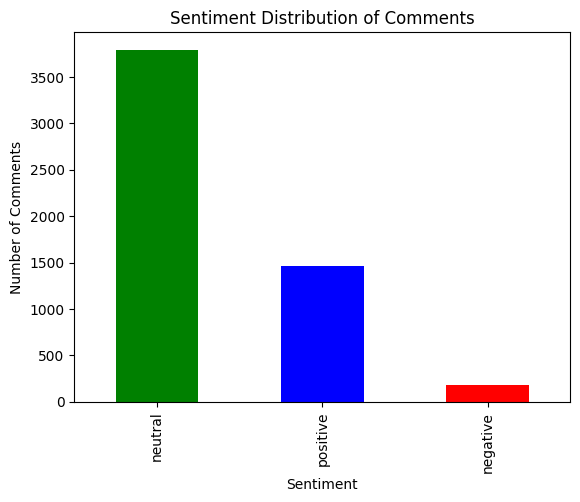

In [33]:
import matplotlib.pyplot as plt

# Count the number of comments for each sentiment label
sentiment_counts = comment['sentiment_label'].value_counts()
sentiment_counts.plot(kind='bar', color=['green', 'blue', 'red'])
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.title('Sentiment Distribution of Comments')
plt.show()


In [34]:
comment.head()

,post_id,ownerUsername,timestamp,comments,likes,clean_comment,sentiment_scores,compound_score,sentiment_label
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!",0.0,i have a proposal for u send me a dm please,"{'neg': 0.0, 'neu': 0.723, 'pos': 0.277, 'comp...",0.3182,positive
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah,0.0,woaaaah,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,neutral
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0,:smiling_face_with_hearteyes::smiling_face_wit...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,neutral
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️,0.0,:red_heart::red_heart::red_heart:,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,neutral
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0,:smiling_face_with_hearteyes::smiling_face_wit...,"{'neg': 0.0, 'neu': 0.646, 'pos': 0.354, 'comp...",0.5095,positive


In [40]:
df = comment.drop(columns=['likes','comments', 'sentiment_scores','compound_score'])
df.head()

,post_id,ownerUsername,timestamp,clean_comment,sentiment_label
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,i have a proposal for u send me a dm please,positive
1,1,mariavmh,2023-06-04 16:46:40+00:00,woaaaah,neutral
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_hearteyes::smiling_face_wit...,neutral
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart::red_heart::red_heart:,neutral
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_hearteyes::smiling_face_wit...,positive


In [ ]:
df.to_csv('comments_processed.csv', index=False)